# Test: Datashader heatmap for 2D scatter (light)

**Date: 03-30-2026**

## Introduction

- This notebook is a lighter test file for developers to test **2D scatter** functions using results from lymphnode_analysis workbook in "../paper/example/lymphnode_analysis.ipynb". 
- All data transformation are omitted while the original section number are kept.

### How to use this notebook for testing

- Make a copy of the notebook in your test branch.
- Pull your code into the branch.
- Make sure the kernel is set as the python environment created from environmental.yml
- Check through the notebook and find cells related to your work. You may delete or comment out unrelated sections. Then write your own testing cells.
- Run cells from top to bottom.

### Dataset Overview
We use the final result from the lymphnode_analysis.ipynb, which is stored in "../data/dev_example.pickle"

Below is the overview of the original dataset
- **Source**: This example uses scimap demo dataset (https://scimap.xyz/tutorials/md/demo_data_scimap/), with additional annotations added for phenotyping analysis named as "example_lymphnode_data.csv". The original data is publicly available normal human lymph node tissue microarray data from CyCIF imaging, preprocessed by MCMICRO. No additional ethical approvals are required for this de-identified published dataset. 
- **Size**: 4,825 cells
- **Markers**: 33 protein markers

## Module Imports & Utility Functions

In [1]:
# Import functions from the updated SPAC package
from spac.data_utils import load_csv_files, select_values, combine_dfs, ingest_cells 
from spac.transformations import arcsinh_transformation, z_score_normalization, run_umap, phenograph_clustering
from spac.visualization import boxplot, histogram, hierarchical_heatmap, dimensionality_reduction_plot, spatial_plot, sankey_plot, visualize_nearest_neighbor, plot_ripley_l
from spac.spatial_analysis import spatial_interaction, calculate_nearest_neighbor, ripley_l
from spac.phenotyping import assign_manual_phenotypes
from spac.transformations import rename_annotations
from functools import partial

import numpy as np
import pandas as pd
from math import ceil, sqrt
import matplotlib.pyplot as plt
import seaborn as sns 
import copy
import anndata
import scanpy as sc
import plotly.io as pio
from PIL import Image as PILImage
from pprint import pprint
from io import BytesIO
%matplotlib inline

# Reduce verbosity settings
import warnings
warnings.filterwarnings('ignore')

# Configure root logger to suppress INFO
# Set logging to only show warnings and errors
import logging
import sys
logging.getLogger().setLevel(logging.WARNING)

# Configure specific loggers
logging.getLogger('spac').setLevel(logging.WARNING)
logging.getLogger('spac.utils').setLevel(logging.WARNING)  # In case of sub-loggers
logging.getLogger('spac.visualization').setLevel(logging.WARNING)

# Also disable propagation to root logger
logging.getLogger('spac').propagate = False

# For scanpy verbosity
sc.settings.verbosity = 1  # Only show errors
# Set visualization parameters
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Suppress matplotlib debug messages
logging.getLogger('matplotlib').setLevel(logging.WARNING)


## Define Input/Output Paths

In [2]:
# Setup file paths
data_pickle = "../data/dev_example.pickle"

## Utility Functions

In [3]:
def generate_grid_frame(adata, fig_width=12, fig_height=12, dpi=300, n_plots=None):
    """Generate a grid frame for multiple subplots."""
    if n_plots is None:
        n_annotations = len(adata.obs.columns.tolist())
    else:
        n_annotations = n_plots
    
    n_cols = ceil(sqrt(n_annotations))
    n_rows = ceil(n_annotations / n_cols)
    
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(fig_width, fig_height),
        dpi=dpi
    )
    axes = axes.flatten()
    return fig, axes

# This function is from https://github.com/FNLCR-DMAP/SPAC_Shiny/blob/main/utils/data_processing.py
def load_data(file_path):
    """
    Load data from a specified file path. Supports .h5ad and .pickle formats.
    
    Parameters:
        file_path (str): The path to the data file.

    Returns:
        adata: Loaded AnnData object or None if loading fails.
    """
    try:
        with open(file_path, 'rb') as file:
            if file_path.endswith('.h5ad'):
                try:
                    adata = ad.read_h5ad(file)
                    return adata
                except Exception as e:
                    print(f"Error loading .h5ad file: {e}")
                    return None
            elif file_path.endswith('.pickle'):
                try:
                    adata = pd.read_pickle(file)
                    return adata
                except Exception as e:
                    print(f"Error loading .pickle file: {e}")
                    return None
            else:
                print("Unsupported file format. Please provide a .h5ad or .pickle file.")
                return None
    except FileNotFoundError:
        print(
            f"Preloaded data file {file_path} not found.",
            "Proceeding without preloaded data."
        )

## Step 1: Data Loading & Preprocessing

### 1.1 Load Pickle Data and Create AnnData Object

In [4]:
# # Load data without verbose output
import io
import contextlib

file_path = data_pickle

# Suppress all output from load_data
with io.StringIO() as buf, contextlib.redirect_stdout(buf):
    preloaded_data = load_data(file_path)

# Get the anndata object
adata = preloaded_data[0] if isinstance(preloaded_data, list) else preloaded_data

print(f"AnnData object created: {adata}")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of features: {adata.n_vars}")
print(f"\nAvailable layers: {list(adata.layers.keys())}")
print(f"Available annotations: {list(adata.obs.columns)}")
print(f"Spatial coordinates: {adata.obsm.keys()}")

AnnData object created: AnnData object with n_obs × n_vars = 4825 × 33
    obs: 'broad_cell_type', 'detailed_cell_type', 'manual_phenotype', 'phenograph_k60_r1', 'renamed_clusters', 'CD3Dspatial_plot', 'CD20spatial_plot'
    uns: 'phenograph_features', 'phenograph_k60_r1_colors', 'renamed_clusters_colors', '_spac_palettes', 'spatial_neighbors', 'renamed_clusters_plot_nhood_enrichment', 'ripley_l_with_edge', 'ripley_l_without_edge', 'ripley_l'
    obsm: 'spatial', 'X_umap', 'spatial_distance'
    layers: 'arcsinh_percentile', 'arcsinh_z_scores'
    obsp: 'spatial_connectivities', 'spatial_distances'
Number of cells: 4825
Number of features: 33

Available layers: ['arcsinh_percentile', 'arcsinh_z_scores']
Available annotations: ['broad_cell_type', 'detailed_cell_type', 'manual_phenotype', 'phenograph_k60_r1', 'renamed_clusters', 'CD3Dspatial_plot', 'CD20spatial_plot']
Spatial coordinates: KeysView(AxisArrays with keys: spatial, X_umap, spatial_distance)


## Step X: Test datashader heatmap

### Testing function definition

In [5]:
from spac.visualization import \
    visualize_2D_datashader_heatmap, \
    visualize_2D_scatter

def test_2D_scatter_and_datashader_heatmap(
    adata,
    x_label='X_umap',
    y_label='X_umap',
    labels=None,
    x_axis_title='UMAP 1',
    y_axis_title='UMAP 2',
    fig_title='UMAP without labels',
    color_representation=None,
    **kwargs,
):
    """
    Test function to visualize 2D scatter and datashader heatmap. 
    Default for UMAP embeddings.
    """
    fig_n_plots = kwargs.get('fig_n_plots', 4)
    fig_width = kwargs.get('fig_width', 10)
    fig_height = kwargs.get('fig_height', 4 * fig_n_plots / 2)
    fig_title_fontsize = kwargs.get('fig_title_fontsize', 16)
    bins = kwargs.get('bins', 50)

    fig, axes = generate_grid_frame(
        adata, fig_width=fig_width, fig_height=fig_height, n_plots=fig_n_plots)
    fig.suptitle(fig_title, fontsize=fig_title_fontsize)

    x = adata.obsm[x_label][:, 0]
    y = adata.obsm[y_label][:, 1]

    # Plot original clusters
    fig, ax = visualize_2D_scatter(
        x=x,
        y=y,
        labels=labels,
        ax=axes[0],
        x_axis_title=x_axis_title,
        y_axis_title=y_axis_title,
        plot_title=f'Original 2D-Scatter',
        color_representation=color_representation
    )

    datashader_flag = kwargs.get('datashader_flag', True)
    if datashader_flag:
        # Plot with datashader heatmap
        for i in range(1, fig_n_plots):
            fig, ax = visualize_2D_datashader_heatmap(
                x=x,
                y=y,
                bins=bins*(2**(i-1)),
                x_axis_title=x_axis_title,
                y_axis_title=y_axis_title,
                plot_title=f'Jeremiah\'s Datashader (bins={bins*(2**(i-1))})',
                ax=axes[i]
            )

    return fig, axes

### X.1 Test without labels

#### UMAP

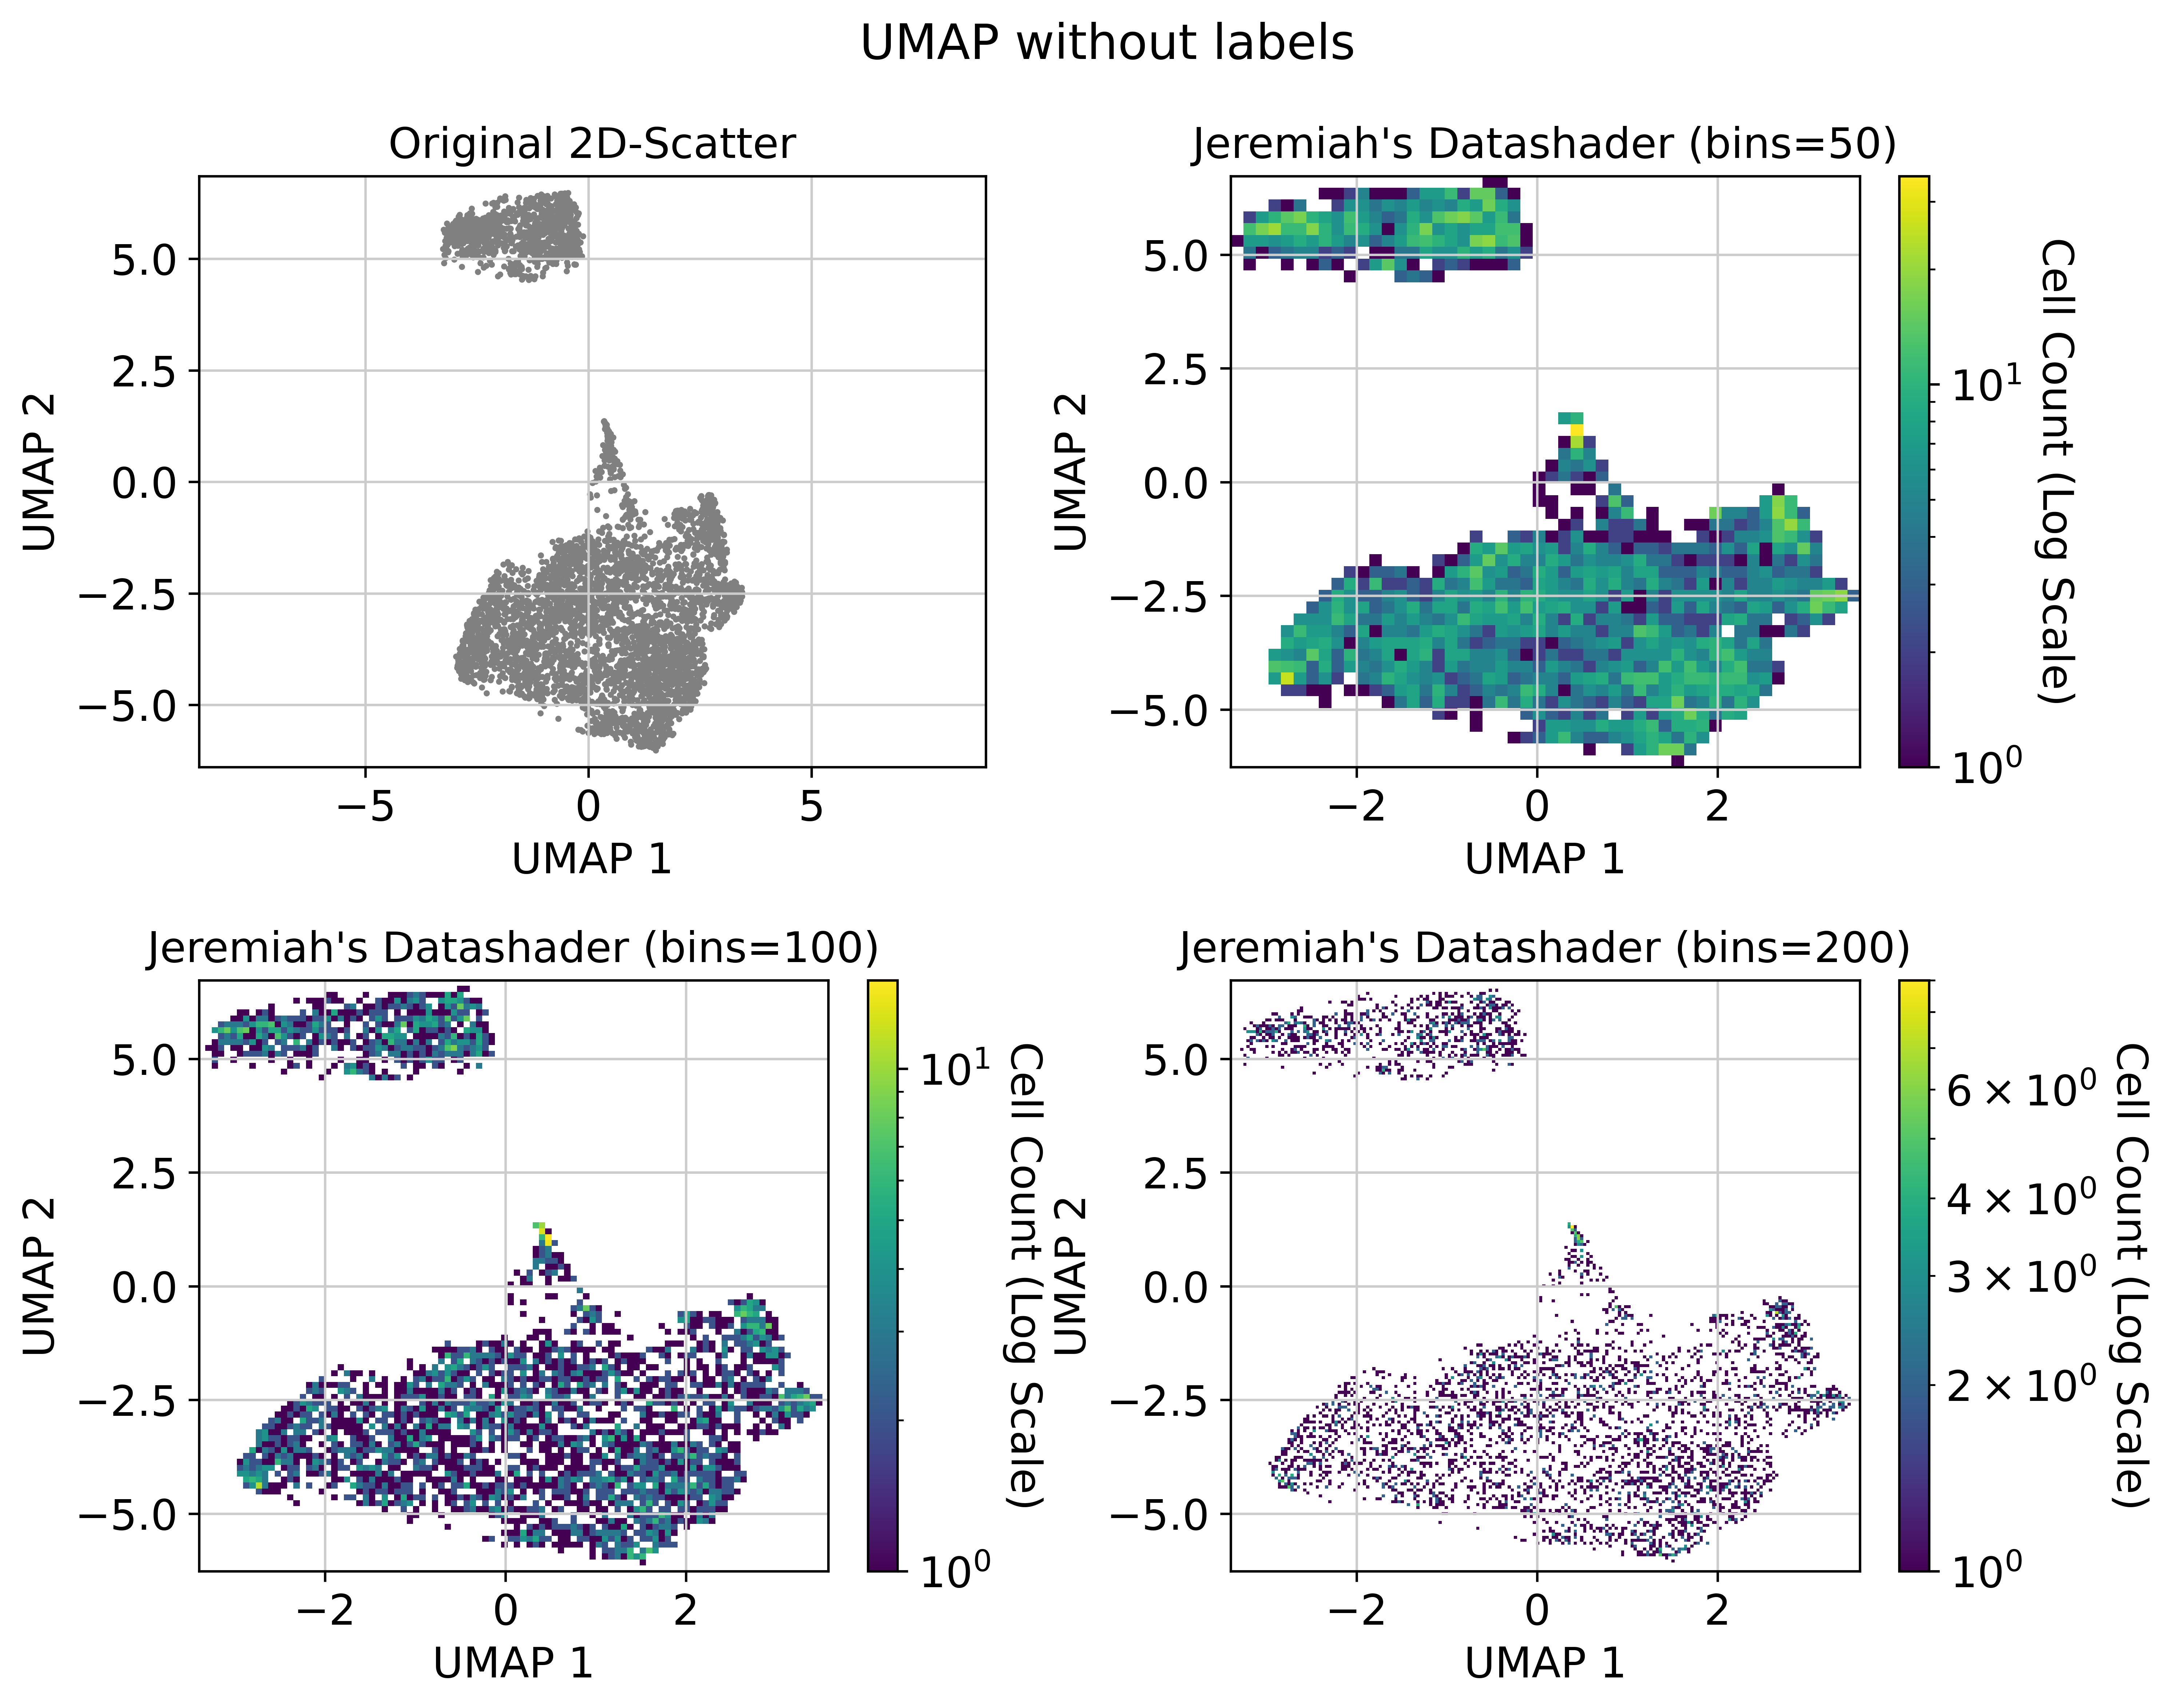

In [6]:
fig, axes = test_2D_scatter_and_datashader_heatmap(
    adata,
    x_label='X_umap',
    y_label='X_umap',
    x_axis_title='UMAP 1',
    y_axis_title='UMAP 2',
    fig_title='UMAP without labels',
)
plt.tight_layout()
plt.show()

#### Spatial

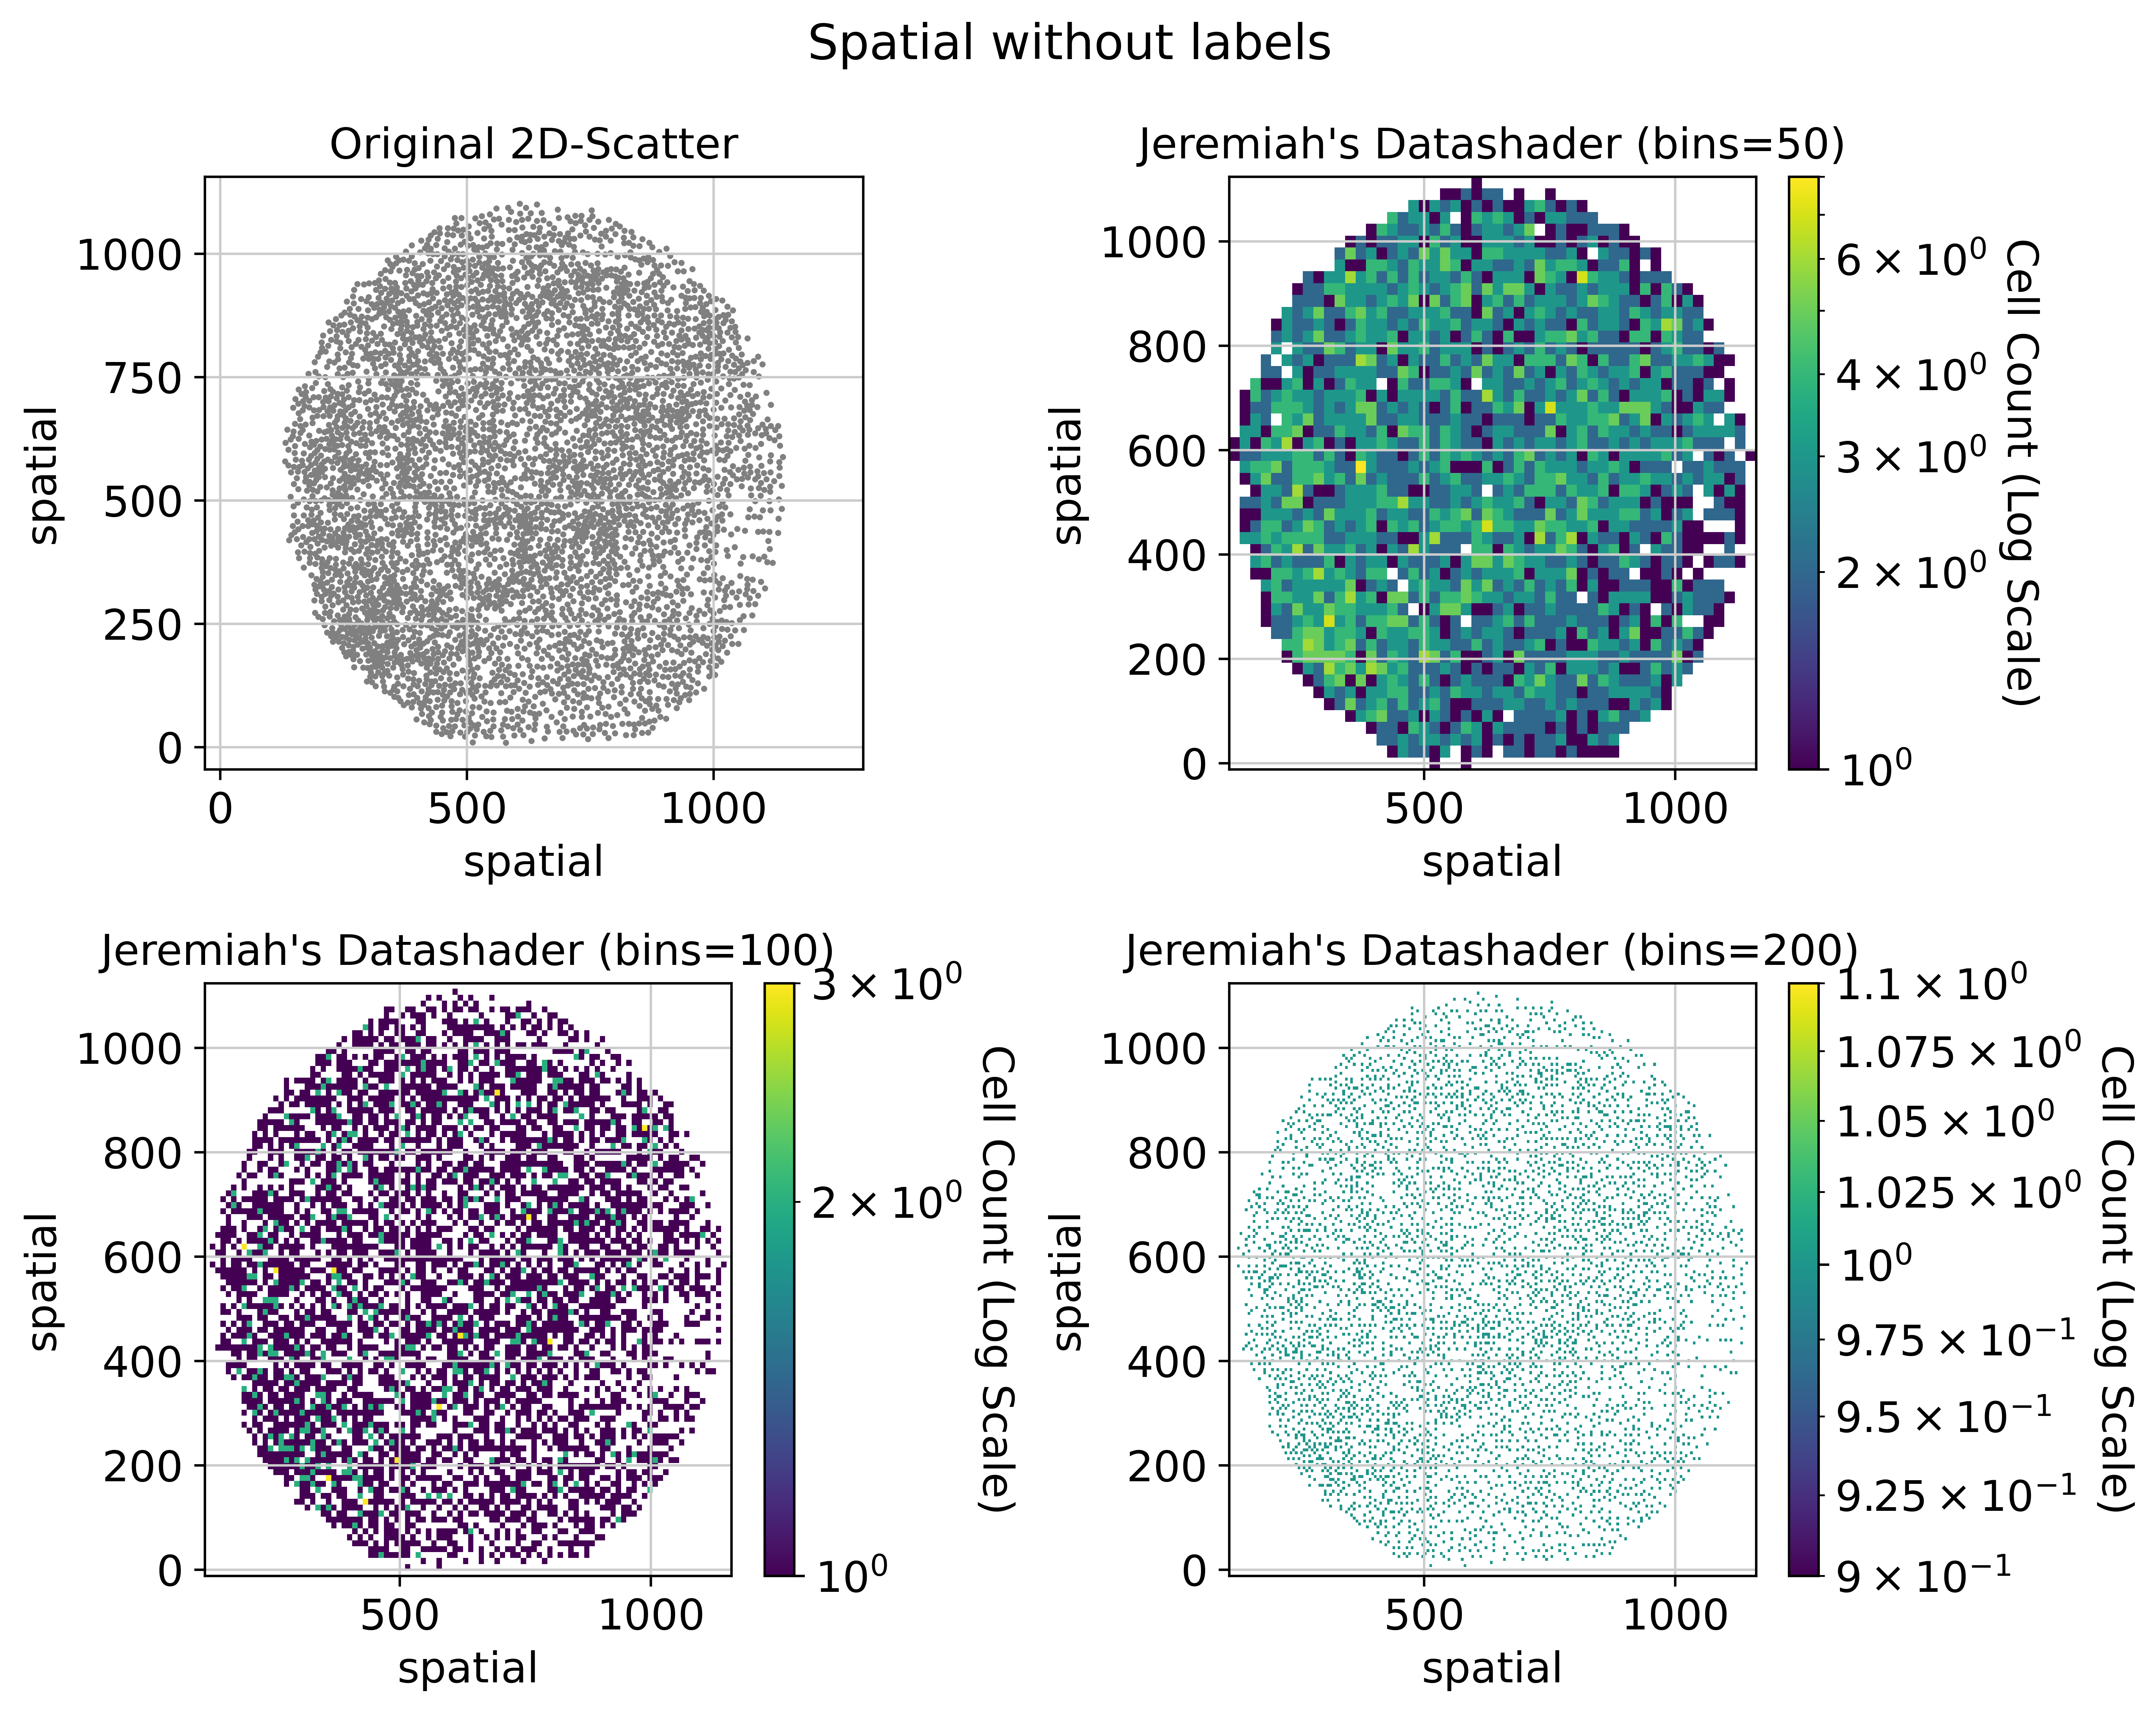

In [7]:
fig, axes = test_2D_scatter_and_datashader_heatmap(
    adata,
    x_label='spatial',
    y_label='spatial',
    x_axis_title='spatial',
    y_axis_title='spatial',
    fig_title='Spatial without labels',
)
plt.tight_layout()
plt.show()

### X.2 DataMine 24-25 team work

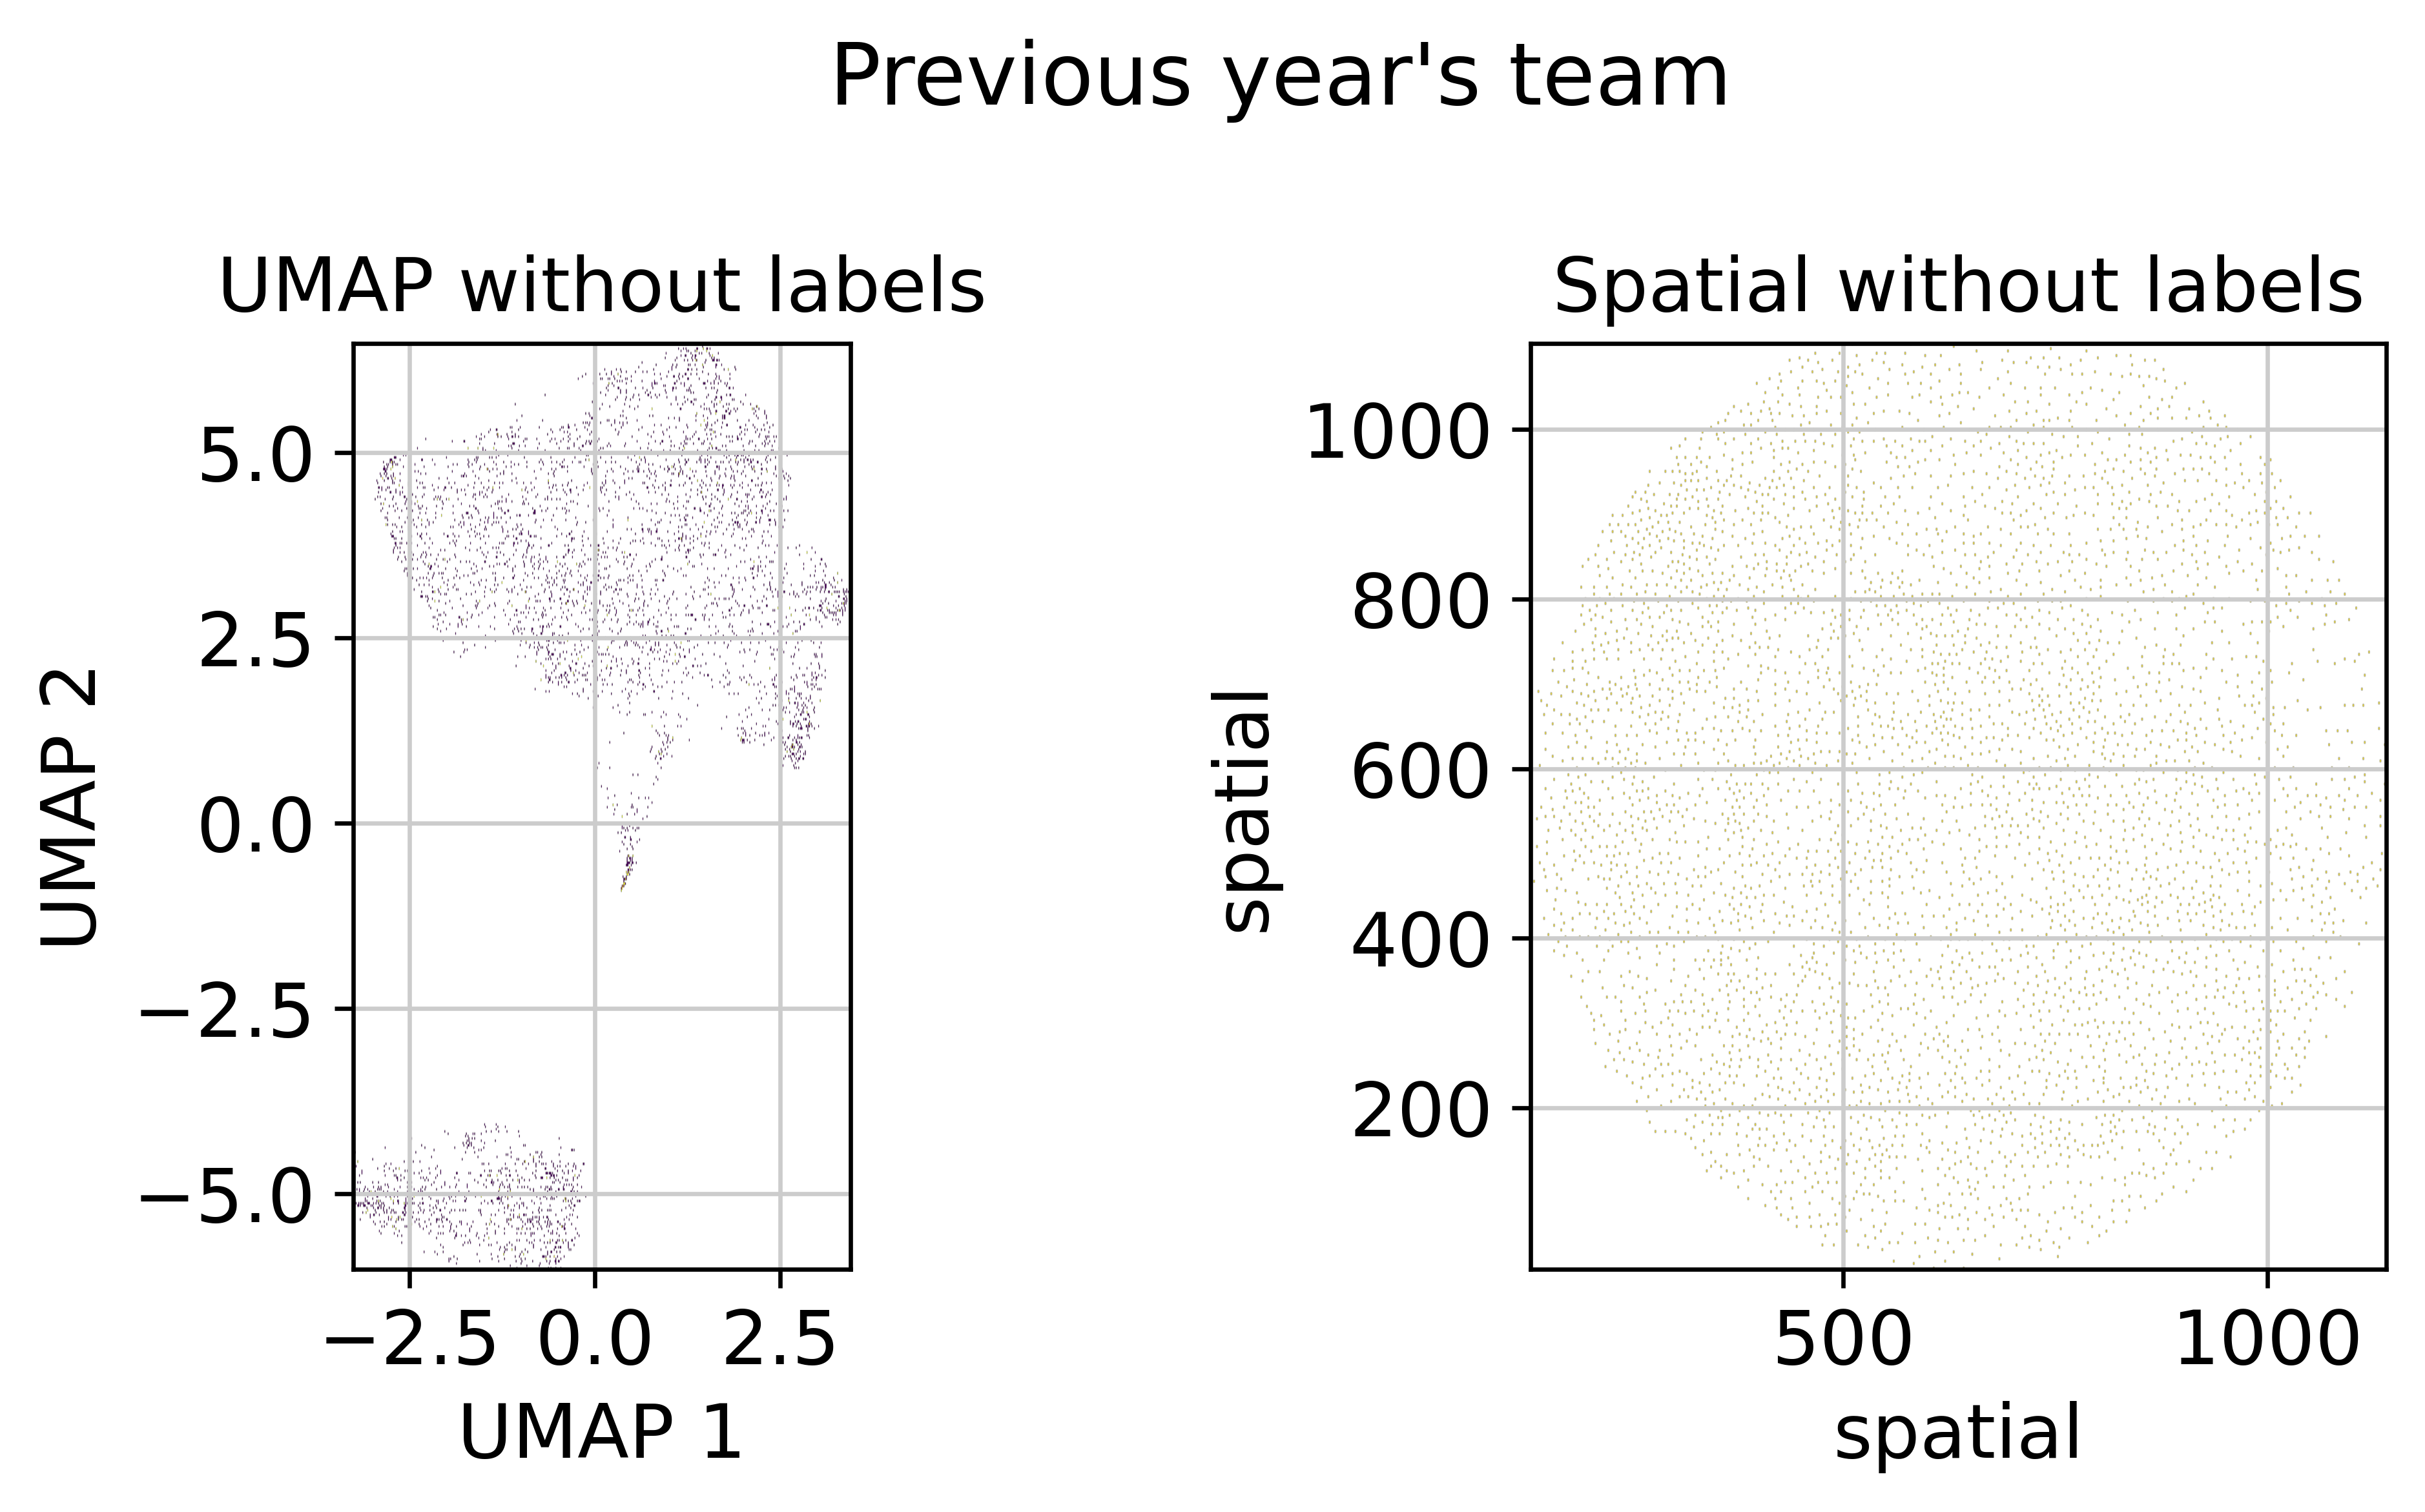

In [8]:
from spac.visualization import \
    visualize_2D_datashader_heatmap, \
    visualize_2D_scatter, \
    heatmap_datashader

kwargs = {}
fig_n_plots = kwargs.get('fig_n_plots', 2)
fig_width = kwargs.get('fig_width', 10)
fig_height = kwargs.get('fig_height', 4 * fig_n_plots / 2)
fig_title = 'Previous year\'s team'
fig_title_fontsize = kwargs.get('fig_title_fontsize', 16)
bins = kwargs.get('bins', 100)

# Generate grid frame for UMAP and spatial plots
fig, axes = generate_grid_frame(
    adata, fig_width=fig_width, fig_height=fig_height, n_plots=2)

# Plot UMAP
x_label = 'X_umap'
y_label = 'X_umap'
x = adata.obsm[x_label][:, 0]
y = adata.obsm[y_label][:, 1]
fig_1 = heatmap_datashader(
    x=x,
    y=y,
    ax=axes[0],
    x_axis_title='UMAP 1',
    y_axis_title='UMAP 2',
    plot_title=f'UMAP without labels',
)

# Plot spatial
x_label = 'spatial'
y_label = 'spatial'
x = adata.obsm[x_label][:, 0]
y = adata.obsm[y_label][:, 1]
fig_2 = heatmap_datashader(
    x=x,
    y=y,    
    ax=axes[1],
    x_axis_title='spatial',
    y_axis_title='spatial',
    plot_title=f'Spatial without labels',
)

# annotation = 'broad_cell_type'
# color_values = adata.obs[annotation] if annotation in adata.obs.columns else None
# fig_3 = heatmap_datashader(
#     x=x,
#     y=y,
#     labels=color_values,
#     ax=axes[2],
#     x_axis_title='X_umap',
#     y_axis_title='X_umap',
#     plot_title=f'UMAP without labels',
# )

fig.suptitle(fig_title, fontsize=fig_title_fontsize)
plt.tight_layout()
plt.show()

### X.3 Test categorical labels

#### UMAP: broad_cell_type

Cluster: B Cells, Points: 1083
Cluster: Other Cells, Points: 1508
Cluster: T Cells, Points: 2234


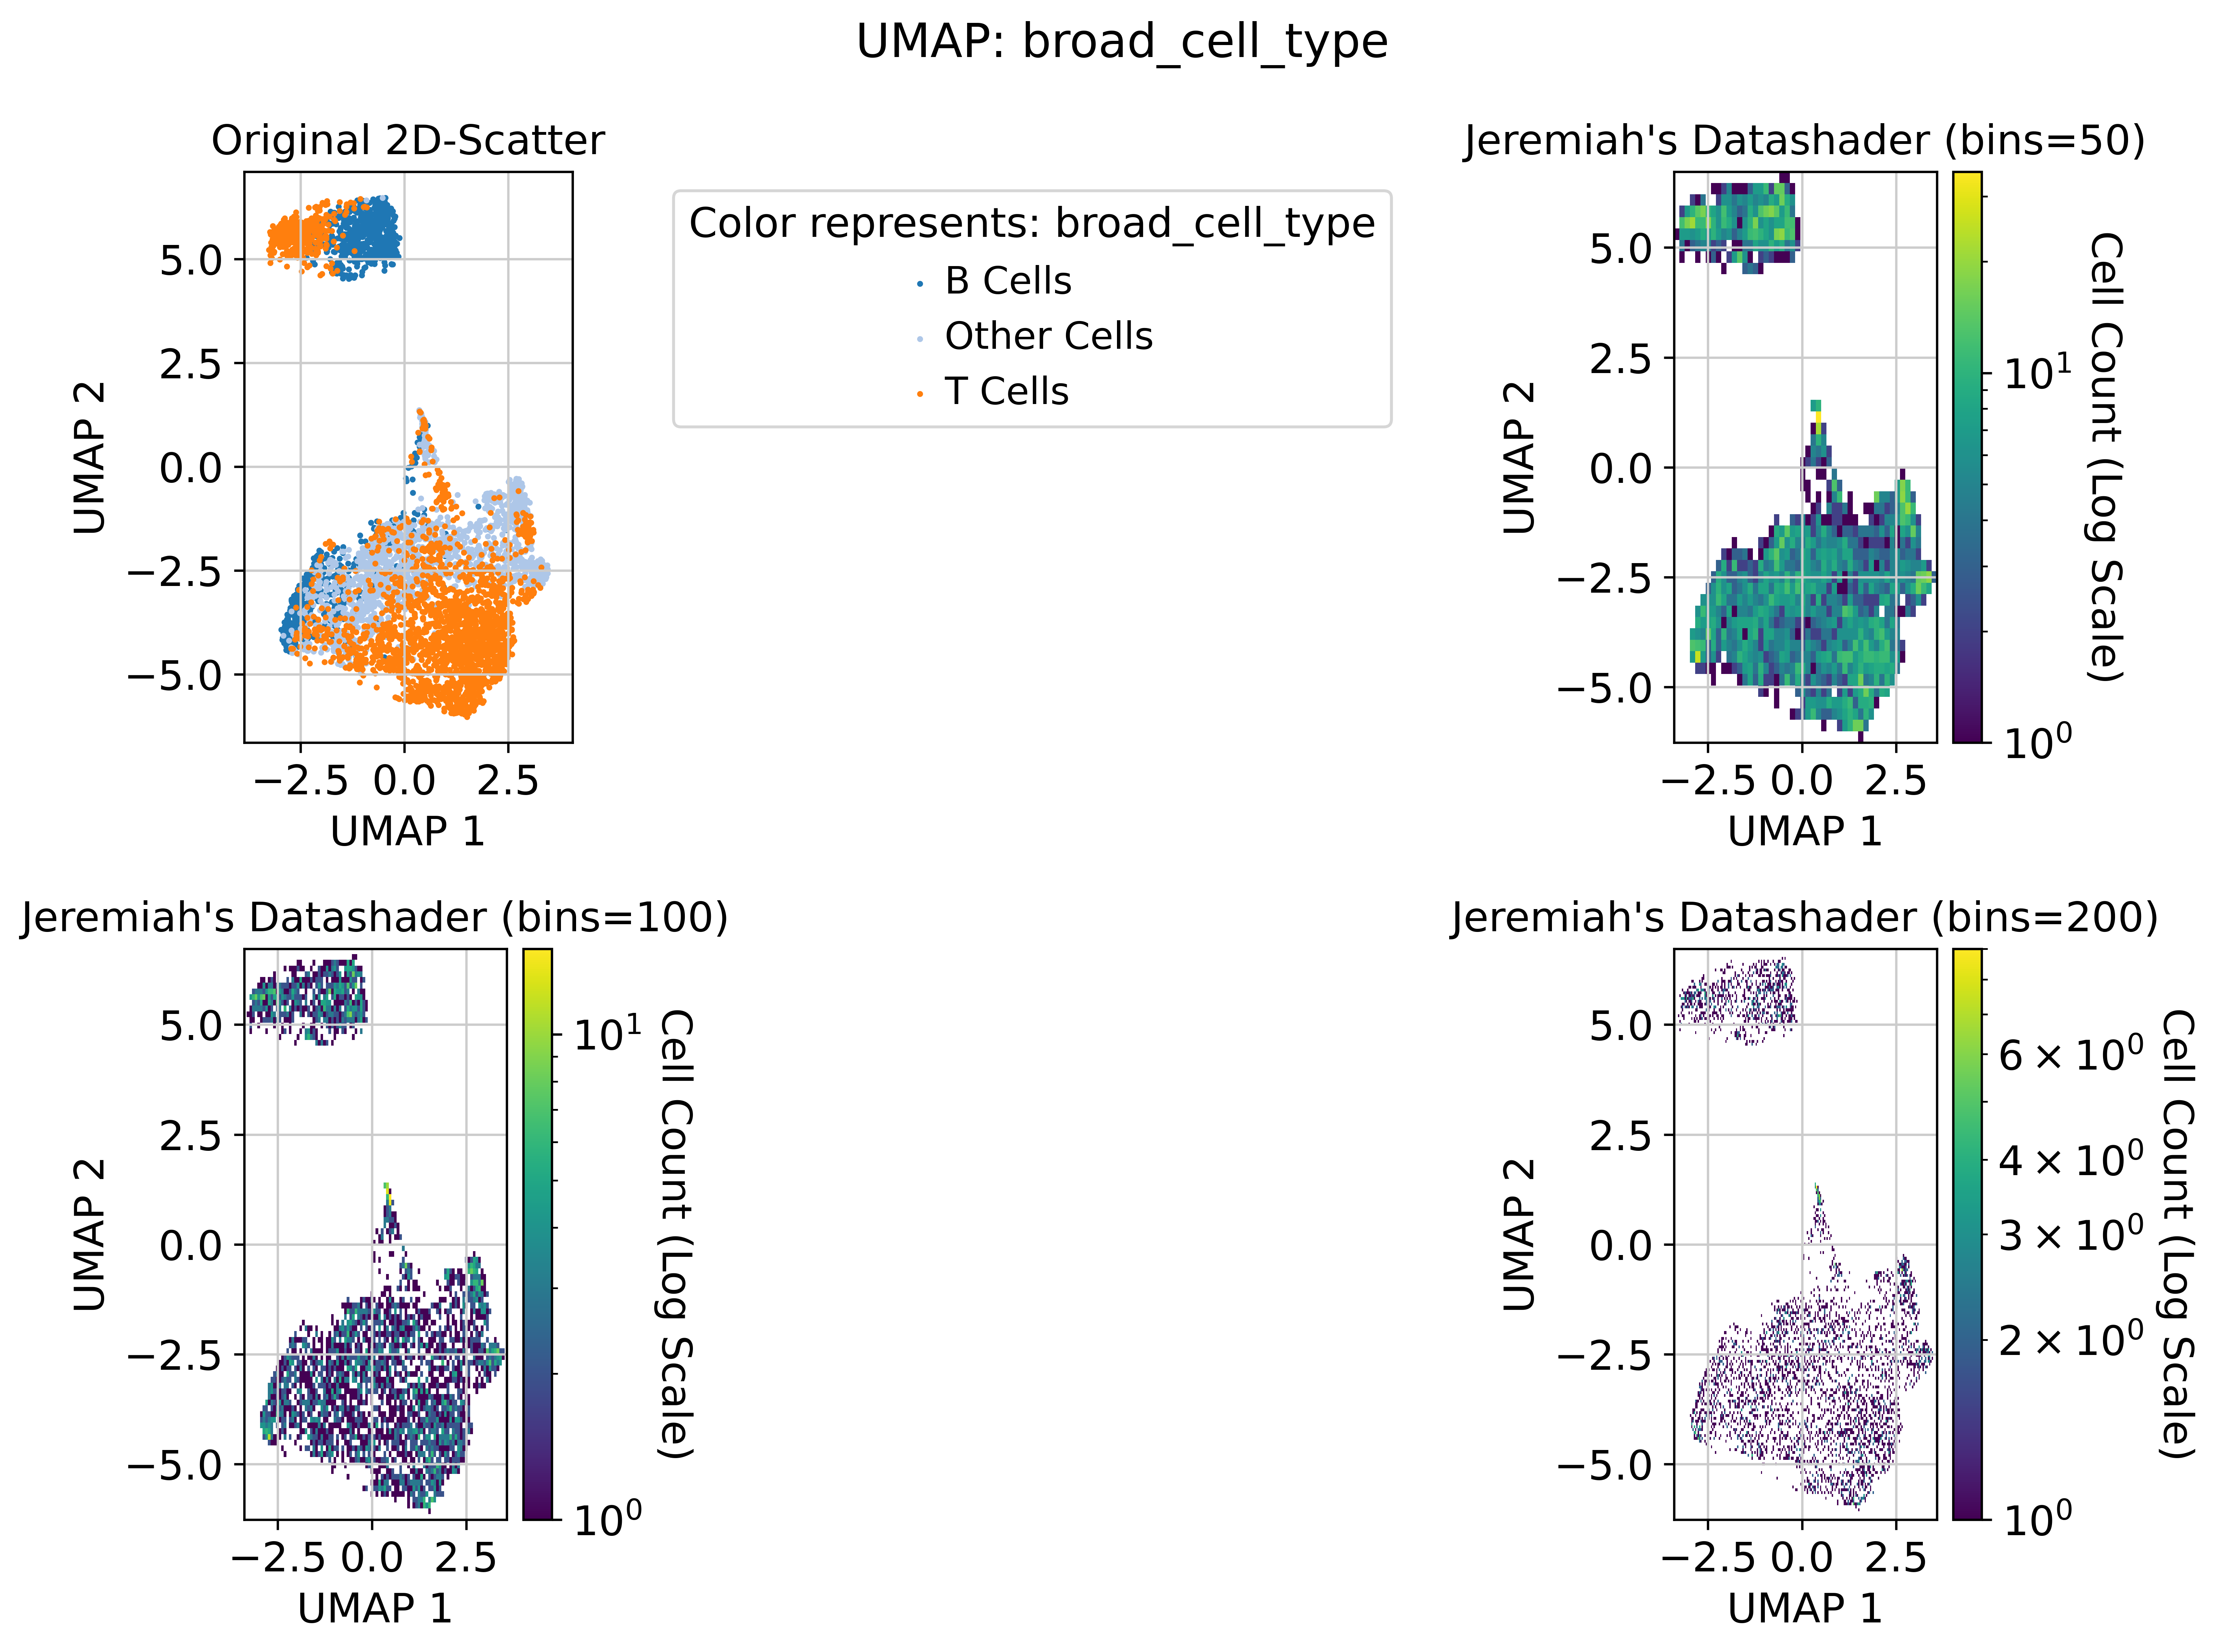

In [9]:
annotation = 'broad_cell_type'
color_values = adata.obs[annotation] if annotation in adata.obs.columns else None
color_representation = annotation
fig, axes = test_2D_scatter_and_datashader_heatmap(
    adata,
    x_label='X_umap',
    y_label='X_umap',
    labels=color_values,
    x_axis_title='UMAP 1',
    y_axis_title='UMAP 2',
    fig_title=f'UMAP: {annotation}',
    color_representation=color_representation,
    # datashader_flag=False
)
plt.tight_layout()
plt.show()

Cluster: ASMA+ cells, Points: 326
Cluster: B cells, Points: 417
Cluster: CD8 T cells, Points: 971
Cluster: Follicular helper T cells (Tfh), Points: 332
Cluster: Myeloid cells, Points: 1453
Cluster: NK cells, Points: 284
Cluster: Others, Points: 126
Cluster: Proliferative B cells, Points: 650
Cluster: Regulatory T cells, Points: 266


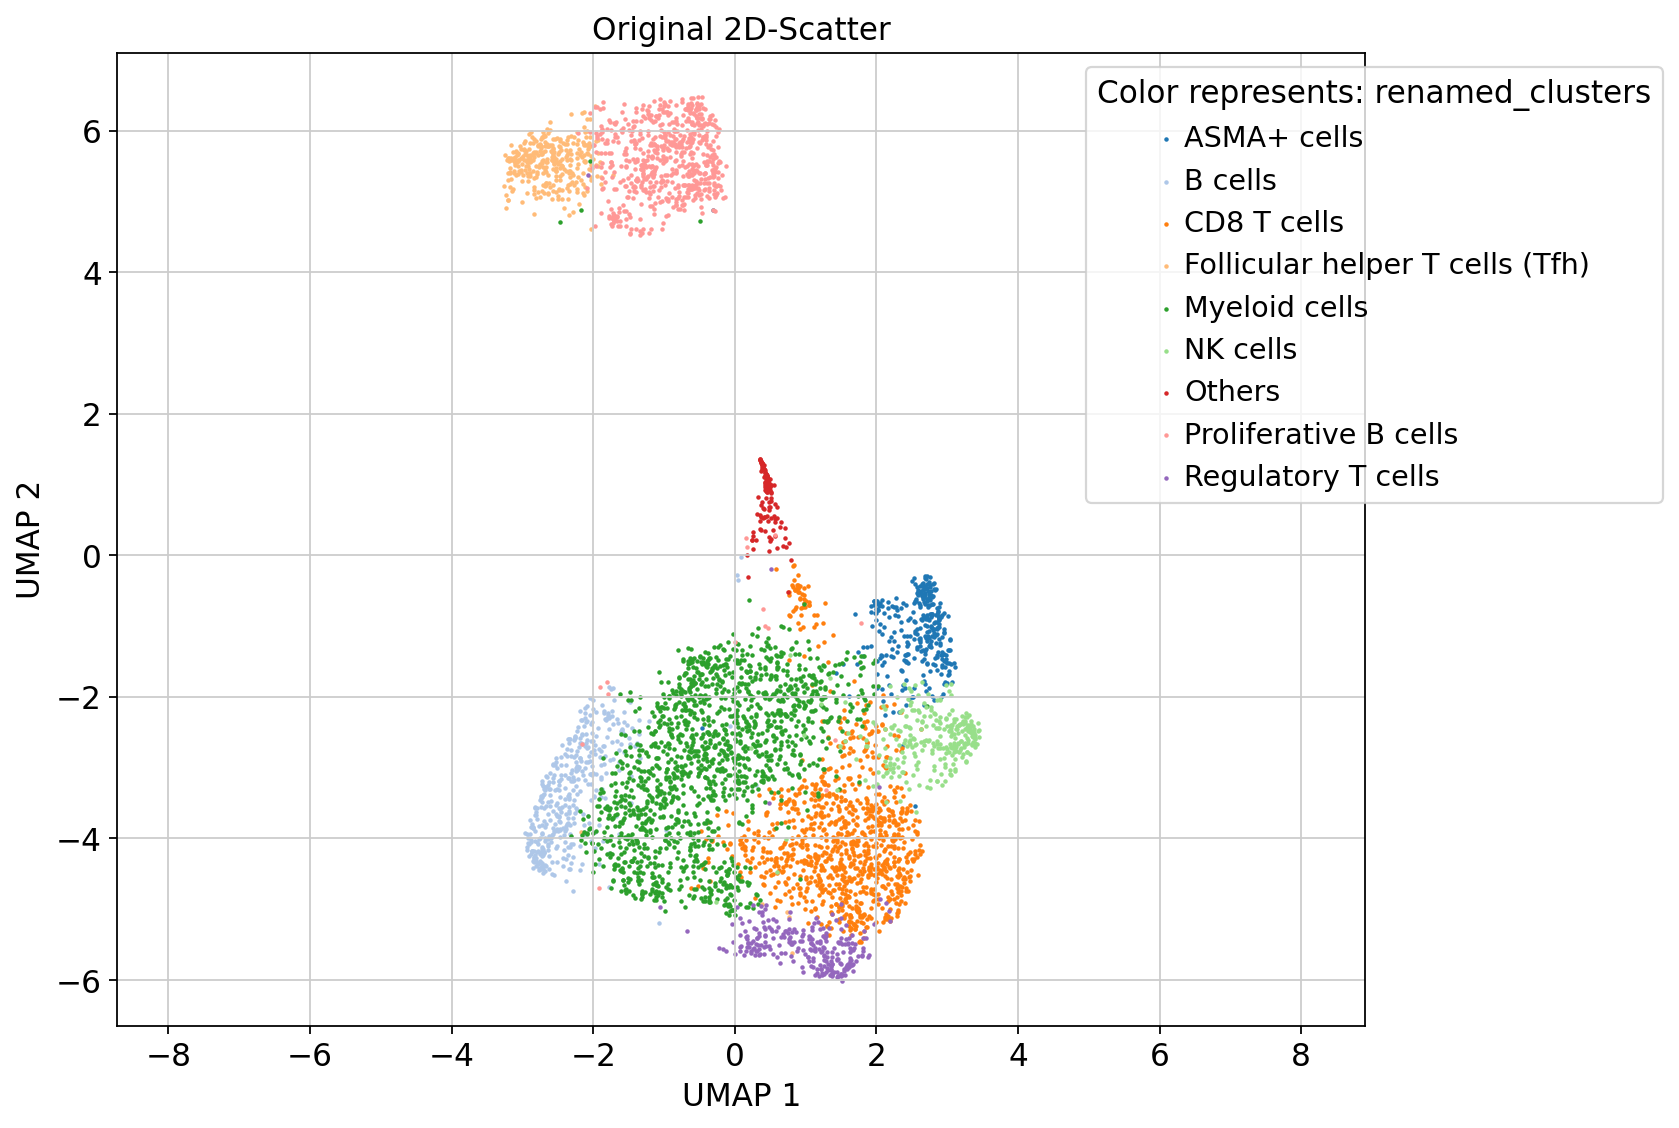

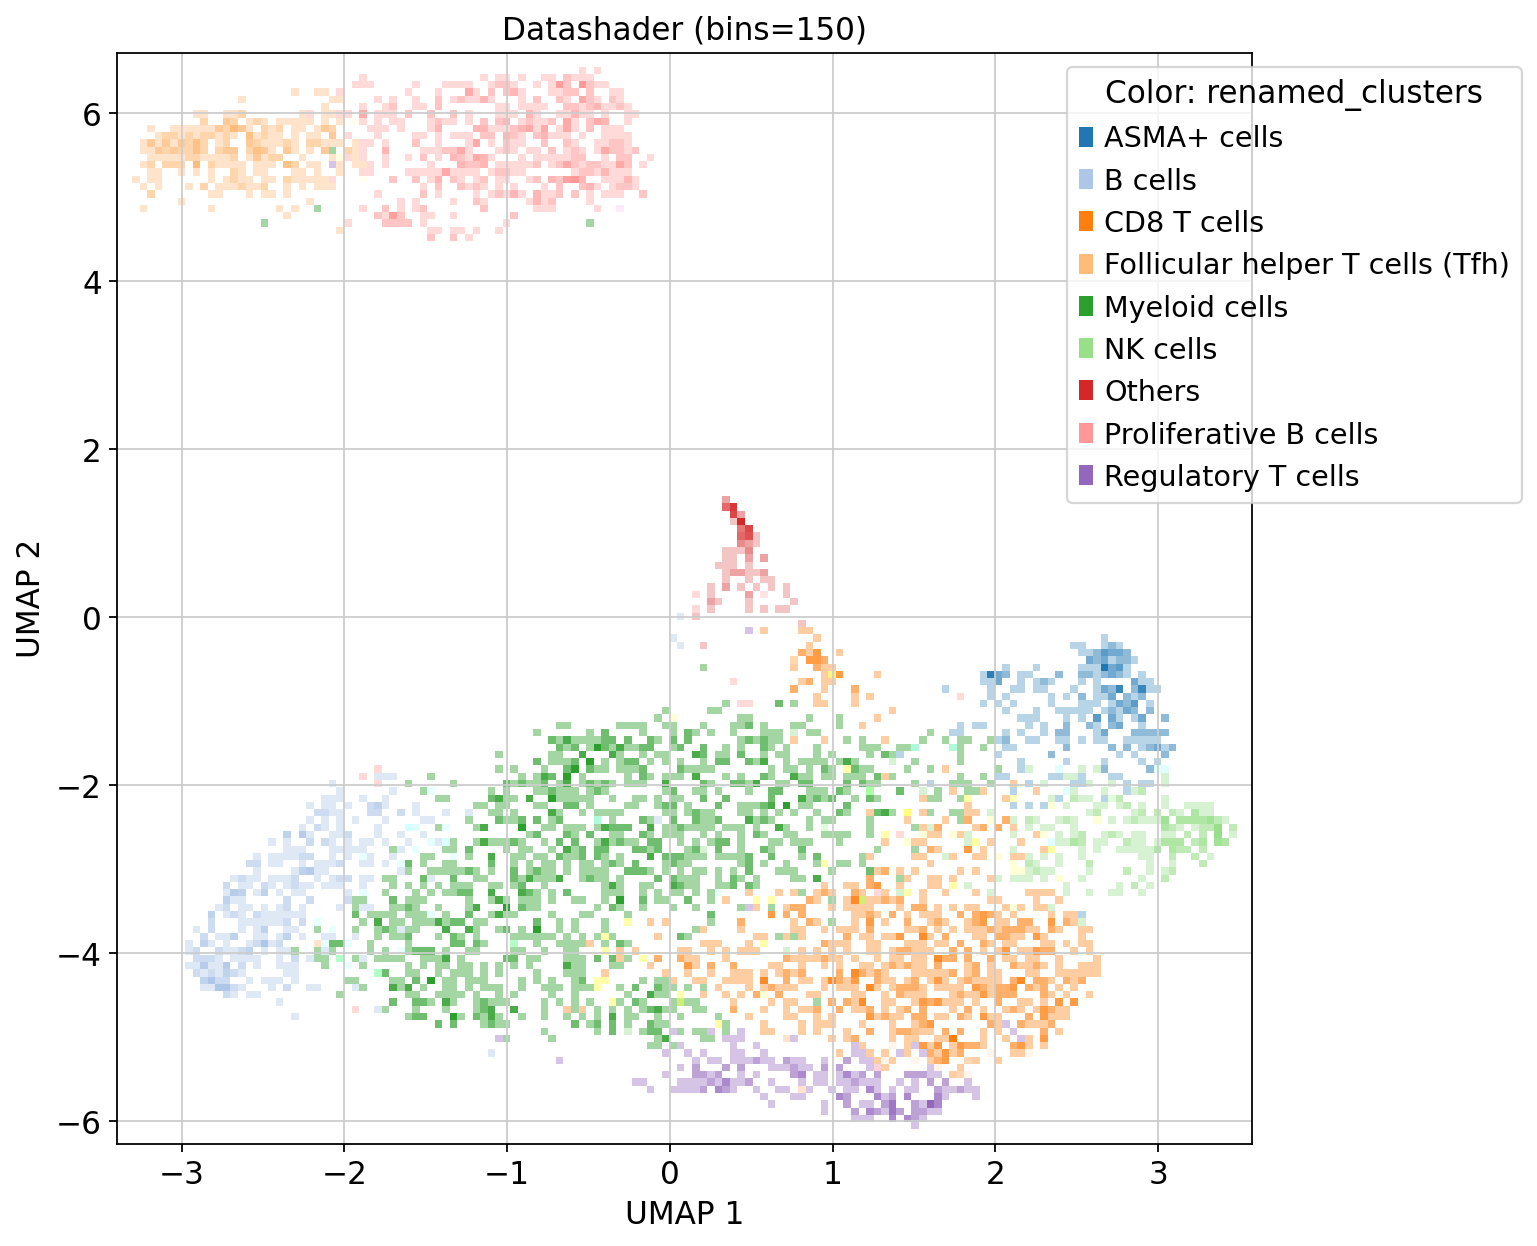

In [ ]:
# Set UMAP coordinates
x_label = 'X_umap'
y_label = 'X_umap'
x = adata.obsm[x_label][:, 0]
y = adata.obsm[y_label][:, 1]
x_axis_title='UMAP 1'
y_axis_title='UMAP 2'

# Set 'broad_cell_type' as the color representation if it exists
annotation = 'renamed_clusters'
color_values = adata.obs[annotation] if annotation in adata.obs.columns else None
color_representation = annotation

# Plot original clusters
fig, ax = visualize_2D_scatter(
    x=x,
    y=y,
    labels=color_values,
    x_axis_title=x_axis_title,
    y_axis_title=y_axis_title,
    plot_title=f'Original 2D-Scatter',
    color_representation=color_representation
)

# Plot with datashader heatmap
bins = 150
fig, ax = visualize_2D_datashader_heatmap(
    x=x,
    y=y,
    labels=color_values,
    bins=bins,
    x_axis_title=x_axis_title,
    y_axis_title=y_axis_title,
    plot_title=f'Datashader (bins={bins})',
    color_representation=color_representation,
)

# Plot with previous year's datashader heatmap
fig = heatmap_datashader(
    x=x,
    y=y,
    labels=color_values,
    x_axis_title=x_axis_title,
    y_axis_title=y_axis_title,
    plot_title=f'Previous year\'s datashader (no labels)',
    color_representation=color_representation,
)

plt.tight_layout()
plt.show()